In [1]:
%pwd

'd:\\Tipto\\Generative-AI\\Advance RAG Topics\\Self-RAG'

*There are basically 3 problems with traditional rag:*
1. RAG Retrieves even when retrieval is unnecessary.
2. RAG blindly trust retrieved documents.
3. RAG doesn't verify its own answers.

*Self-RAG* stands for Self Reflective RAG where the LLM actively judges its own retrieval, evidence and answers instead of blindly trusting retrieved documents.

LLM does not the self reflection by questioning the system like:
- Should retrieval happen?
- Are the retrieved documents relevant?
- Is the generated response grounded in the retrieved documents?
- Does the response actually answer the query?

In [2]:
from langchain_ollama import ChatOllama
phi_model = ChatOllama(
    model = "phi4-mini:latest",
    temperature = 0.0
)

qwen_model = ChatOllama(
    model = "qwen2.5:7b-instruct",
    temperature = 0.2
)

In [3]:
from langchain_community.document_loaders import PyPDFLoader

# load the pdf and merge them
docs = (
    PyPDFLoader("./data/Company_Policies.pdf").load() +
    PyPDFLoader("./data/Company_Profile.pdf").load() +
    PyPDFLoader("./data/Product_and_Pricing.pdf").load()
)
docs[0].page_content[ : 500]

C:\Users\tipto\AppData\Local\Temp\ipykernel_6720\4189922056.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


'NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6'

In [4]:
# do the chunking 
from langchain_text_splitters import RecursiveCharacterTextSplitter
chunks = RecursiveCharacterTextSplitter(
    chunk_size = 600,
    chunk_overlap = 150
).split_documents(docs)
len(chunks)

16

In [5]:
chunks[0]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './data/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: As per

In [6]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["HUGGINGFACEHUB_API_TOKEN"] = os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-mpnet-base-v2",
    model_kwargs = {"device": device},
    encode_kwargs = {"normalize_embeddings": True}
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [9]:
from langchain_chroma import Chroma
vector_store = Chroma(
    collection_name = "self_rag",
    embedding_function = embedding_model,
    persist_directory="./data/chroma"
)

In [10]:
# add the chunks
vector_store.add_documents(chunks)

['f32252d9-e84f-4b43-af2c-e1b7b7d72150',
 'c5021c68-d8df-41db-a0cc-8fd278e763f0',
 '3cdb1053-1e1e-4014-8059-3a893fec6a72',
 '4af8798e-a472-4563-a3e6-da5b08cb9b45',
 '68820229-9082-478a-885a-21902e4ca051',
 '567e7cf5-13dd-4a0c-8030-ff600d0ff699',
 '42d0c713-b733-4449-846f-0d3713cea8c0',
 '3d665bb5-7e37-4f6c-b927-a7365a72dc95',
 'bde71c61-137e-404a-bdd6-6291fa463fbb',
 '2ce297d6-7c22-418f-8037-f458b1106be2',
 '5fdbb360-7ea0-4f08-8294-b423158410a4',
 '5cc46298-5f5e-4888-91fb-7e03ea271166',
 'a8325872-b8b8-48f1-8458-f254e4fa3b96',
 '770833b2-267d-4713-9bd1-e1483722ae9a',
 'b4c61ac2-ad94-430e-8c1f-76a1fee9a08b',
 '15672e5a-89e4-4d18-87f5-965415e03482']

In [11]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})
retriever

VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x0000019A972611D0>, search_kwargs={'k': 3})

In [12]:
vector_store._collection.count()

32

In [13]:
retriever.invoke("Who is the CEO of the NexaAI?")

[Document(id='f7e69af3-7c50-47a8-8a61-2f9d9fc7e172', metadata={'source': './data/Company_Profile.pdf', 'creator': '(unspecified)', 'trapped': '/False', 'author': '(anonymous)', 'keywords': '', 'producer': 'ReportLab PDF Library - www.reportlab.com', 'title': '(anonymous)', 'total_pages': 2, 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'page_label': '2', 'page': 1}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\x7f\nKunal Sharma – Head of Product\n\x7f\nNeha Verma – Head of Operations & HR\n

In [14]:
# define the agent state
from typing import List
from pydantic import BaseModel, Field
from langchain_core.documents import Document
class AgentState(BaseModel):
    question: str = Field(..., description="The question to be answered by the agent.")
    need_retrieval: bool = Field(..., description="Indicates whether the agent needs to perform retrieval.")
    
    docs: List[Document] = Field(default_factory=list, description="The documents retrieved by the agent.")
    relevant_docs: List[Document] = Field(default_factory=list, description="The relevant documents selected by the agent.")
    web_query: str = Field(default="", description="The web query generated by the agent for additional information.")
    answer: str = Field(default="", description="The final answer generated by the agent.")

In [30]:
# a pydantic model for rerieved or not
from langchain_core.prompts import ChatPromptTemplate

class IsRetrievalNeeded(BaseModel):
    need_retrieval: bool = Field(..., description="Whether retrieval is needed for the question. True if retrieval is needed, False otherwise.")

# decision_retrieval_prompt = ChatPromptTemplate([
#     ("system", 
#      ("You are a helpful assistant that determines whether retrieval is needed for a given question.\n", "Return a JSON object with a single key: {{'need_retrieval': boolean}}\n\n", "Guidelines:\n- If the question is general or can be answered without external information, return False.\n- If the question requires specific information from documents or external sources, return True.\n\n")
#     ),
#     ("human", "Question: {{question}}\n\n")
# ])

decision_retrieval_prompt = ChatPromptTemplate([
    (
        "system",
        (
            "You are a helpful assistant that determines whether retrieval is needed for a given question.\n"
            "Return a JSON object with a single key: {{'need_retrieval': boolean}}\n\n"
            "Guidelines:\n"
            "- If the question is general knowledge, basic math, unit conversions, or can be answered without external documents, return False.\n"
            "- If the question requires specific information from private documents, internal company data, or external sources, return True.\n\n"
            "Examples:\n"
            "Question: What is 2 + 2?\n"
            "{{'need_retrieval': false}}\n\n"
            "Question: How many seconds in an hour?\n"
            "{{'need_retrieval': false}}\n\n"
            "Question: Who is the CEO of Nexa-AI?\n"
            "{{'need_retrieval': true}}\n"
        ),
    ),
    ("human", "Question: {question}\n\n"),
])

should_retrieve_llm = phi_model.with_structured_output(IsRetrievalNeeded)

# retrieval needed or not decision node
def retrieval_decision_node(agent_state: AgentState):
    decision: IsRetrievalNeeded = should_retrieve_llm.invoke(
        decision_retrieval_prompt.format_prompt(
            question=agent_state.question
        )
    )
    
    return {
        "need_retrieval": decision.need_retrieval
    }

In [31]:
# now make the retrieval node
def retrieval_node(agent_state: AgentState):
    if agent_state.need_retrieval:
        # retrieve the documents from the Chroma vector store
        retrieved_docs = retriever.invoke(agent_state.question)
        return {
            "docs": retrieved_docs
        }

In [36]:
# create direct answer node
def direct_answer_node(agent_state: AgentState):
    # create a prompt for direct answer
    direct_answer_prompt = ChatPromptTemplate([
        ("system", "You are a helpful assistant that provides direct answers to questions based on the your parametric knowledge. If you do not know the answer, respond with 'I don't know.'"),
        ("human", "Question: {question}")
    ])
    response = phi_model.invoke(
        direct_answer_prompt.format_prompt(
            question=agent_state.question
        )
    )
    return {
        "answer": response.content
    }

In [37]:
# create routing funtion for direct answer or retrieval
def routing_after_need_retrieval_node(agent_state: AgentState):
    if agent_state.need_retrieval:
        return "retrieval_node"
    
    return "direct_answer_node"

In [41]:
# make a node which will select relevant docs from the retrieved docs
class IsRelevantDoc(BaseModel):
    is_relevant: bool = Field(..., description="Whether the document is relevant to the question. True if relevant, False otherwise.")

# create a prompt for relevance check
relevance_prompt = ChatPromptTemplate([
    ("system", "You are a helpful assistant that determines whether a document is relevant to a given question. Return True if the document is relevant, otherwise return False."),
    ("human", "Question: {question}\nDocument: {document}\nIs the document relevant to the question? (True/False)")
])
relevance_llm = phi_model.with_structured_output(IsRelevantDoc)
  
def keep_relevant_docs_node(agent_state: AgentState):
    relevant_docs = []
    for doc in agent_state.docs:
        decision: IsRelevantDoc = relevance_llm.invoke(
            relevance_prompt.format_prompt(
                question=agent_state.question,
                document=doc.page_content
            )
        )
        if decision.is_relevant:
            relevant_docs.append(doc)
    
    return {
        "relevant_docs": relevant_docs
    }

In [48]:
# make a node which will generate the answer based on the relevant docs
def answer_from_relevant_docs_node(agent_state: AgentState):
    # create a prompt for answer generation from relevant docs
    answer_from_docs_prompt = ChatPromptTemplate([
        ("system", "You are a helpful assistant that generates an answer to a question based on the provided relevant documents. If the documents do not contain enough information to answer the question, respond with 'I don't know.'"),
        ("human", "Question: {question}\nRelevant Documents: {relevant_docs}\nGenerate an answer based on the relevant documents.")
    ])
    response = phi_model.invoke(
        answer_from_docs_prompt.format_prompt(
            question=agent_state.question,
            relevant_docs="\n\n".join([doc.page_content for doc in agent_state.relevant_docs])
        )
    )
    return {
        "answer": response.content
    }

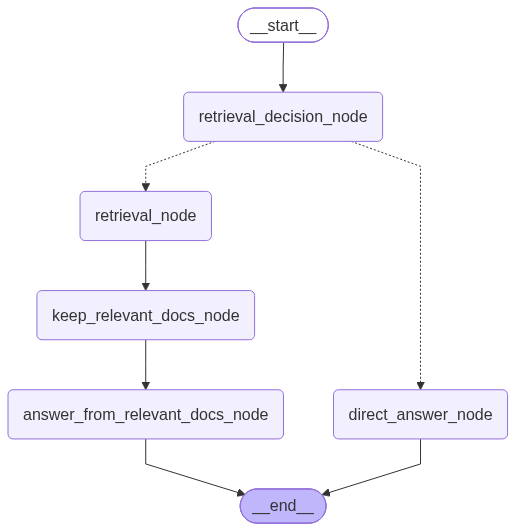

In [49]:
from langgraph.graph import  StateGraph, START, END

graph = StateGraph(state_schema = AgentState)

# create the nodes
graph.add_node("retrieval_decision_node", retrieval_decision_node)
graph.add_node("retrieval_node", retrieval_node)
graph.add_node("direct_answer_node", direct_answer_node)
graph.add_node("keep_relevant_docs_node", keep_relevant_docs_node)
graph.add_node("answer_from_relevant_docs_node", answer_from_relevant_docs_node)


# add edges
graph.add_edge(START, "retrieval_decision_node")
# based on the decision, route to either retrieval or direct answer
graph.add_conditional_edges(
    "retrieval_decision_node",
    routing_after_need_retrieval_node,
    {
        "retrieval_node": "retrieval_node",
        "direct_answer_node": "direct_answer_node"
    }
)
# if retrieval is not needed, then go to direct answer node and then to end
graph.add_edge("direct_answer_node", END)
# if retrieval is needed
graph.add_edge("retrieval_node", "keep_relevant_docs_node")
graph.add_edge("keep_relevant_docs_node", "answer_from_relevant_docs_node")
graph.add_edge("answer_from_relevant_docs_node", END)

workflow = graph.compile()
workflow

In [50]:
result = workflow.invoke({
    "question": "Who is the CEO of the Nexa-AI?",
    "need_retrieval": False,
    "docs": [],
    "relevant_docs": [],
    "web_query": ""
})
# result = workflow.invoke({
#     "question": "How many hours in a day?",
#     "need_retrieval": False,
#     "docs": [],
#     "relevant_docs": [],
#     "web_query": ""
# })
result

{'question': 'Who is the CEO of the Nexa-AI?',
 'need_retrieval': True,
 'docs': [Document(id='f7e69af3-7c50-47a8-8a61-2f9d9fc7e172', metadata={'total_pages': 2, 'moddate': '2026-02-14T13:07:17+00:00', 'creator': '(unspecified)', 'source': './data/Company_Profile.pdf', 'page': 1, 'keywords': '', 'trapped': '/False', 'title': '(anonymous)', 'producer': 'ReportLab PDF Library - www.reportlab.com', 'page_label': '2', 'author': '(anonymous)', 'subject': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00'}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\

In [51]:
result["answer"]

'The CEO and Founder of Nexa-AI is Aarav Mehta.'